# Part 1 — Capital Bikeshare Demand Analysis & Forecasting
**PhD Technical Assessment — Dr. Sohn's Research Lab, UNLV**

This notebook covers:
- **Task 1:** Descriptive Statistics & Exploratory Analysis
- **Task 2:** Statistical & Regression Analysis
- **Task 3:** Demand Forecasting & Predictive Modeling (leakage-safe train/test split)

**Dataset:** [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (Fanaee-T & Gama, 2013) — hourly Capital Bikeshare rentals, Washington D.C., 2011–2012.

> **Note on the data:** The raw `hour.csv` file ships with `temp`, `atemp`, `hum`, and `windspeed` **normalized to [0, 1]** rather than in their original physical units. The assessment brief describes these as Celsius/percent/raw wind speed, so this notebook de-normalizes them back to physical units immediately after loading (using the min/max bounds documented in the dataset's `Readme.txt`) and keeps both versions available for modeling.


## 0. Setup

In [1]:
# If running in Google Colab, uncomment the line below on first run
# !pip install -q statsmodels scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests, zipfile, io
import warnings

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42


## 1. Data Loading

Downloads the official UCI zip directly. If your environment has no outbound internet access
(rare on Colab, but possible on some managed instances), download the zip manually from
the link above, upload `hour.csv` to the Colab session, and skip to the fallback cell.


In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

try:
    r = requests.get(DATA_URL, timeout=30)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall("bike_data")
    print("Downloaded and extracted:", z.namelist())
except Exception as e:
    print("Automatic download failed:", e)
    print("Manually download the zip from https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset,")
    print("upload hour.csv via the Colab file browser, and set the path in the next cell accordingly.")


Downloaded and extracted: ['Readme.txt', 'day.csv', 'hour.csv']


In [3]:
# Fallback: if you uploaded hour.csv manually, point this at it instead
HOUR_CSV_PATH = "bike_data/hour.csv"

df_raw = pd.read_csv(HOUR_CSV_PATH)
df_raw.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
# --- Build a clean working frame ---
df = df_raw.copy()

df['dteday'] = pd.to_datetime(df['dteday'])
df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')

# De-normalize temp/atemp/hum/windspeed back to physical units (per UCI Readme.txt)
# temp:  t_norm = (t - t_min) / (t_max - t_min),  t_min=-8,  t_max=+39   (Celsius)
# atemp: same formula, t_min=-16, t_max=+50                              (Celsius)
# hum:   normalized by dividing by 100 (max)                            (percent, 0-100)
# windspeed: normalized by dividing by 67 (max)                         (units as recorded, ~m/s scale)
df['temp_c']      = df['temp']      * (39 - (-8)) + (-8)
df['atemp_c']     = df['atemp']     * (50 - (-16)) + (-16)
df['humidity_pct']= df['hum']       * 100
df['windspeed_raw'] = df['windspeed'] * 67

# Rename to assessment-brief-friendly names, keep originals too
df = df.rename(columns={
    'weathersit': 'weather',
    'cnt': 'count'
})

df = df.sort_values('datetime').reset_index(drop=True)
df['day_of_month'] = df['dteday'].dt.day
df['month_year'] = df['dteday'].dt.to_period('M')
df['dow_name'] = df['datetime'].dt.day_name()

print(df.shape)
df[['datetime','season','yr','mnth','hr','holiday','workingday','weather',
    'temp_c','atemp_c','humidity_pct','windspeed_raw','casual','registered','count']].head()


(17379, 25)


,datetime,season,yr,mnth,hr,holiday,workingday,weather,temp_c,atemp_c,humidity_pct,windspeed_raw,casual,registered,count
0,2011-01-01 00:00:00,1,0,1,0,0,0,1,3.28,3.0014,81.0,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,1,1,0,0,1,2.34,1.9982,80.0,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,1,2,0,0,1,2.34,1.9982,80.0,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,1,3,0,0,1,3.28,3.0014,75.0,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,1,4,0,0,1,3.28,3.0014,75.0,0.0,0,1,1


In [5]:
# Sanity checks
print("Date range:", df['datetime'].min(), "to", df['datetime'].max())
print("\nMissing values per column:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate datetimes:", df['datetime'].duplicated().sum())
print("\ncasual + registered == count check (mismatches):",
      (df['casual'] + df['registered'] != df['count']).sum())


Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00

Missing values per column:
 Series([], dtype: int64)

Duplicate datetimes: 0

casual + registered == count check (mismatches): 0


---
## Task 1: Descriptive Statistics & Exploratory Analysis


In [6]:
df[['count','casual','registered','temp_c','atemp_c','humidity_pct','windspeed_raw']].describe().T


,count,mean,std,min,25%,50%,75%,max
count,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,977.0000
casual,17379.0,35.676218,49.305030,0.00,4.0000,17.0000,48.0000,367.0000
registered,17379.0,153.786869,151.357286,0.00,34.0000,115.0000,220.0000,886.0000
temp_c,17379.0,15.358397,9.050138,-7.06,7.9800,15.5000,23.0200,39.0000
atemp_c,17379.0,15.401157,11.342114,-16.00,5.9978,15.9968,24.9992,50.0000
humidity_pct,17379.0,62.722884,19.292983,0.00,48.0000,63.0000,78.0000,100.0000
windspeed_raw,17379.0,12.736540,8.196795,0.00,7.0015,12.9980,16.9979,56.9969


### 1.1 Overall demand over time

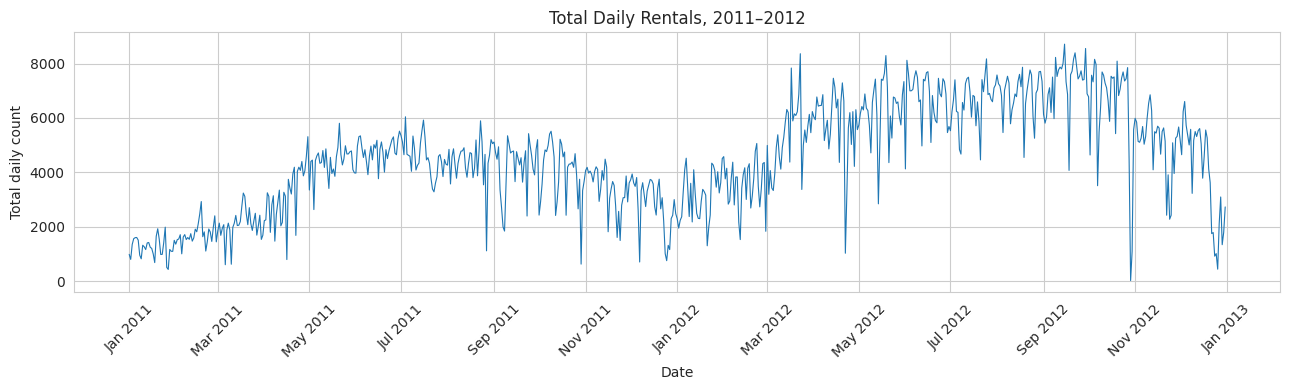

In [8]:
daily = df.groupby('dteday')['count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(daily['dteday'], daily['count'], linewidth=0.8)
ax.set_title('Total Daily Rentals, 2011–2012')
ax.set_xlabel('Date'); ax.set_ylabel('Total daily count')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 1.2 Hourly pattern — working day vs. non-working day
This is the single clearest signature in bikeshare data: registered/commuter demand should show twin rush-hour peaks on working days, while casual/leisure demand should show a single midday hump on weekends.

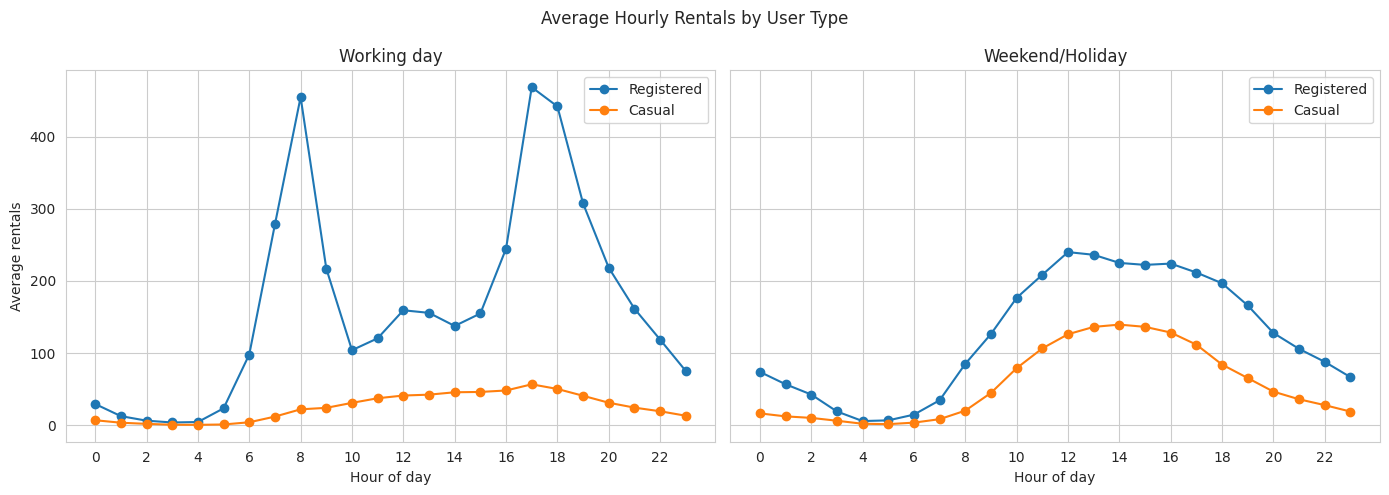

In [9]:
hourly_avg = df.groupby(['hr','workingday'])[['count','casual','registered']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
for wd, label, ax in [(1, 'Working day', axes[0]), (0, 'Weekend/Holiday', axes[1])]:
    sub = hourly_avg[hourly_avg['workingday']==wd]
    ax.plot(sub['hr'], sub['registered'], marker='o', label='Registered')
    ax.plot(sub['hr'], sub['casual'], marker='o', label='Casual')
    ax.set_title(label)
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(0,24,2))
    ax.legend()
axes[0].set_ylabel('Average rentals')
plt.suptitle('Average Hourly Rentals by User Type')
plt.tight_layout()
plt.show()


### 1.3 Seasonal and weather effects

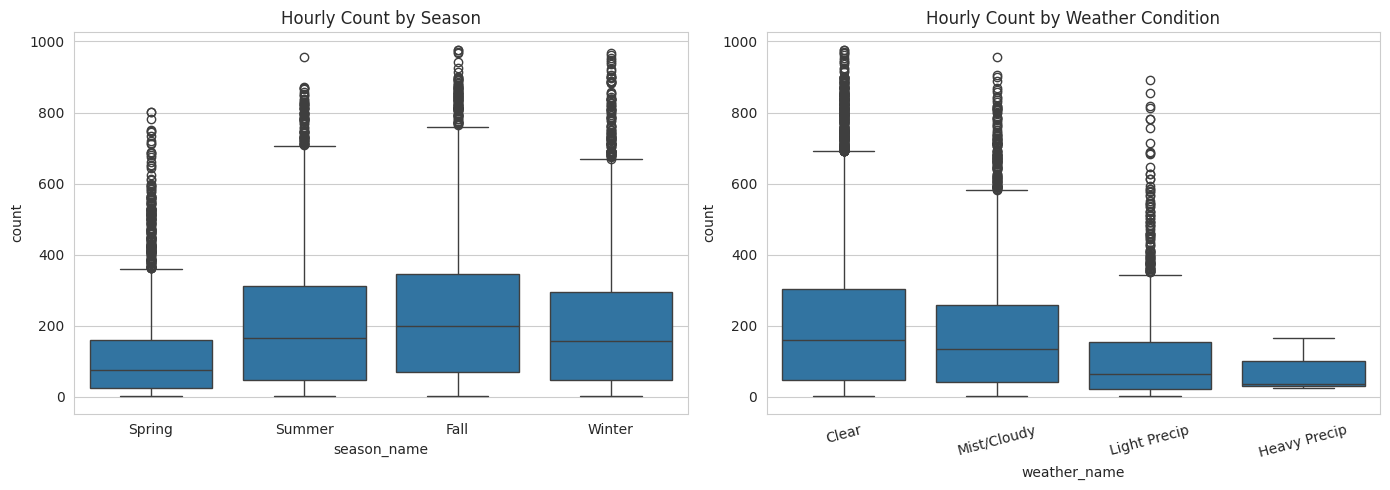

                    mean  median  count
weather_name                           
Clear         204.869272   159.0  11413
Heavy Precip   74.333333    36.0      3
Light Precip  111.579281    63.0   1419
Mist/Cloudy   175.165493   133.0   4544


In [10]:
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Mist/Cloudy', 3:'Light Precip', 4:'Heavy Precip'}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df.assign(season_name=df['season'].map(season_map)),
            x='season_name', y='count', order=['Spring','Summer','Fall','Winter'], ax=axes[0])
axes[0].set_title('Hourly Count by Season')

sns.boxplot(data=df.assign(weather_name=df['weather'].map(weather_map)),
            x='weather_name', y='count',
            order=['Clear','Mist/Cloudy','Light Precip','Heavy Precip'], ax=axes[1])
axes[1].set_title('Hourly Count by Weather Condition')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(df.assign(weather_name=df['weather'].map(weather_map)).groupby('weather_name')['count'].agg(['mean','median','count']))


### 1.4 Casual vs. registered: weekday/weekend split and temperature sensitivity

Average hourly rentals by day type:
                     casual  registered
workingday                            
Weekend/Holiday  57.441422  123.963910
Working day      25.561315  167.646439 



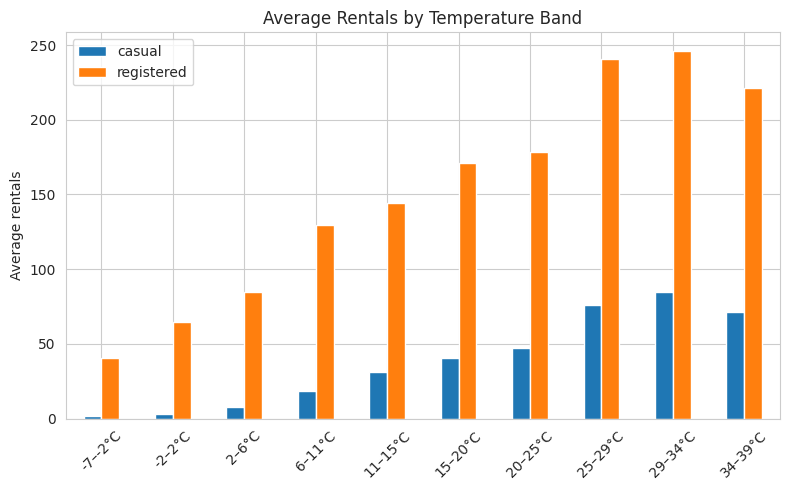

In [12]:
weekday_split = df.groupby('workingday')[['casual','registered']].mean()
weekday_split.index = weekday_split.index.map({1:'Working day', 0:'Weekend/Holiday'})
print("Average hourly rentals by day type:\n", weekday_split, "\n")

fig, ax = plt.subplots(figsize=(8,5))
temp_bins = pd.cut(df['temp_c'], bins=10)
temp_effect = df.groupby(temp_bins)[['casual','registered']].mean()
temp_effect.index = [f"{int(i.left)}–{int(i.right)}°C" for i in temp_effect.index]
temp_effect.plot(kind='bar', ax=ax)
ax.set_title('Average Rentals by Temperature Band')
ax.set_ylabel('Average rentals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 1.5 Anomalies worth flagging
count hours during blizzards, the 2012 Hurricane Sandy dip (late Oct 2012), holiday dips despite good
weather, etc.

In [13]:
# Zero/very-low-count hours (candidate anomalies / extreme weather events)
low_count = df[df['count'] <= 5].copy()
print("Hours with count <= 5:", len(low_count))
print(low_count.groupby('dteday').size().sort_values(ascending=False).head(10))

# Extreme weather hours
print("\nHeavy precipitation (weather=4) hours:")
print(df[df['weather']==4][['datetime','count','weather','temp_c']])

# Year-over-year growth (2011 vs 2012), same months only
yoy = df.groupby('yr')['count'].sum()
print("\nTotal rentals by year (0=2011, 1=2012):\n", yoy, f"\nGrowth: {(yoy[1]/yoy[0]-1)*100:.1f}%")


Hours with count <= 5: 1081
dteday
2011-12-25    7
2011-01-10    6
2011-02-02    6
2011-04-13    5
2011-03-01    5
2011-01-17    5
2012-01-12    5
2011-02-21    5
2011-03-02    5
2012-12-27    5
dtype: int64

Heavy precipitation (weather=4) hours:
                datetime  count  weather  temp_c
585  2011-01-26 16:00:00     36        4    2.34
8854 2012-01-09 18:00:00    164        4    1.40
9123 2012-01-21 01:00:00     23        4   -1.42

Total rentals by year (0=2011, 1=2012):
 yr
0    1243103
1    2049576
Name: count, dtype: int64 
Growth: 64.9%


---
## Task 2: Statistical & Regression Analysis

**Modeling approach:** `count` is a non-negative integer (count data) with a strongly right-skewed,
over-dispersed distribution — a plain OLS/Gaussian linear model will misspecify the variance structure
and can predict negative counts. We:
1. Confirm over-dispersion (Var >> Mean) to justify moving beyond Poisson to Negative Binomial.
2. Check multicollinearity among predictors (VIF) before finalizing the feature set.
3. Fit and compare OLS (baseline/interpretability), Poisson GLM, and Negative Binomial GLM.
4. Fit separate models for `casual` and `registered` since Section 1 showed they respond very differently to `workingday`.


### 2.1 Distributional diagnostics

Mean(count)     = 189.46
Variance(count) = 32901.46
Variance/Mean ratio = 173.66  (>>1 indicates over-dispersion)


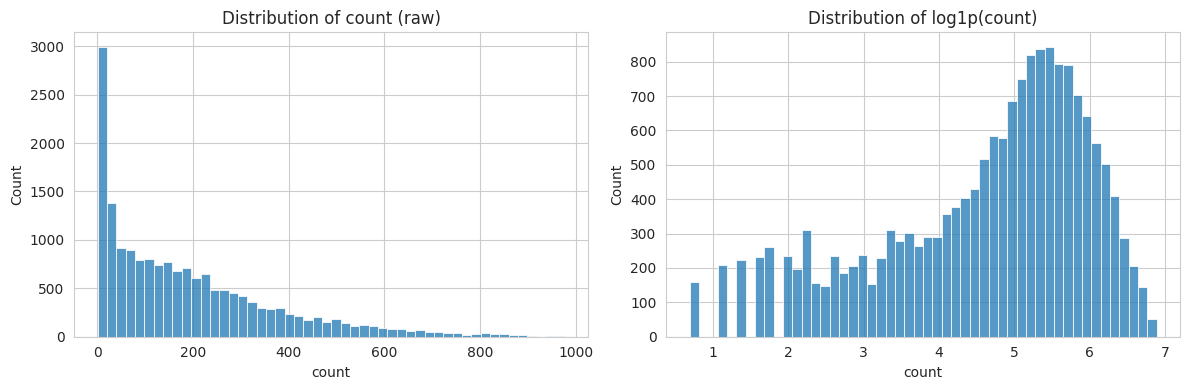

In [14]:
print(f"Mean(count)     = {df['count'].mean():.2f}")
print(f"Variance(count) = {df['count'].var():.2f}")
print(f"Variance/Mean ratio = {df['count'].var()/df['count'].mean():.2f}  (>>1 indicates over-dispersion)")

fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['count'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of count (raw)')
sns.histplot(np.log1p(df['count']), bins=50, ax=axes[1])
axes[1].set_title('Distribution of log1p(count)')
plt.tight_layout()
plt.show()


### 2.2 Multicollinearity check (VIF)

In [15]:
candidate_num = ['temp_c','atemp_c','humidity_pct','windspeed_raw']
X_vif = sm.add_constant(df[candidate_num])
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_df)
print("\ntemp_c vs atemp_c correlation:", df['temp_c'].corr(df['atemp_c']).round(3))
# temp and atemp are typically near-collinear (corr > 0.98); we drop atemp_c and keep temp_c.


         feature        VIF
0          const   1.000000
1         temp_c  43.550327
2        atemp_c  43.651270
3   humidity_pct   1.100575
4  windspeed_raw   1.156293

temp_c vs atemp_c correlation: 0.988


### 2.3 Correlation overview

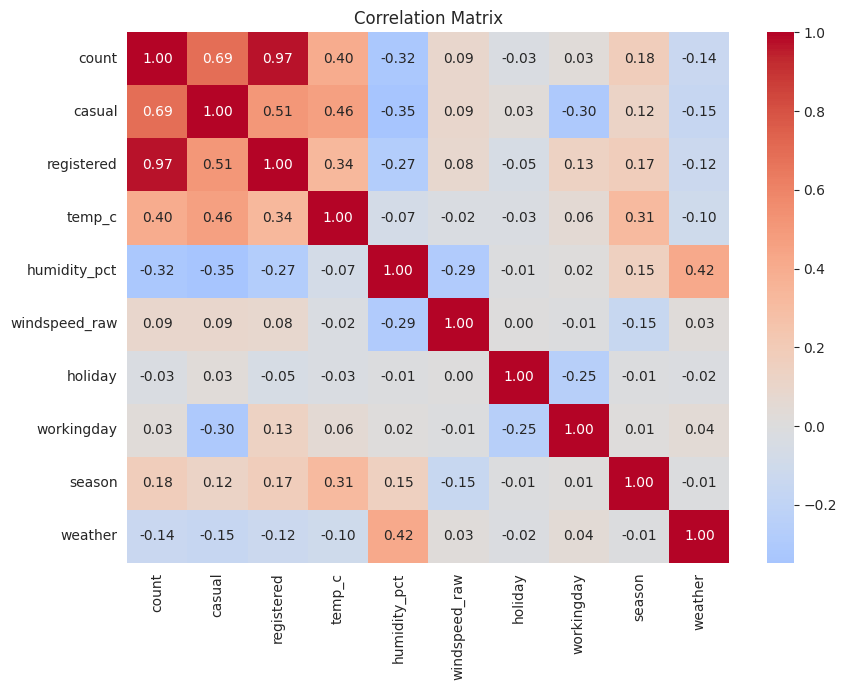

In [16]:
corr_cols = ['count','casual','registered','temp_c','humidity_pct','windspeed_raw','holiday','workingday','season','weather']
plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


### 2.4 Model fitting: OLS vs. Poisson vs. Negative Binomial (target = `count`)
Categorical predictors (`season`, `weather`, `dow_name`... ) are treated as categorical via
`C()` in the formula API so statsmodels dummy-encodes them automatically.

In [17]:
formula = ("count ~ temp_c + humidity_pct + windspeed_raw + workingday + holiday "
           "+ C(season) + C(weather) + C(hr)")

# OLS baseline
ols_model = smf.ols(formula, data=df).fit()

# Poisson GLM
poisson_model = smf.glm(formula, data=df, family=sm.families.Poisson()).fit()

# Negative Binomial GLM (alpha estimated via auxiliary OLS on Poisson residuals, standard approach)
nb_model = smf.glm(formula, data=df, family=sm.families.NegativeBinomial()).fit()

print("=== Model comparison (lower AIC/BIC = better fit) ===")
print(f"{'Model':<20}{'LogLik':>15}{'AIC':>15}{'Deviance':>15}")
print(f"{'OLS':<20}{ols_model.llf:>15.1f}{ols_model.aic:>15.1f}{'--':>15}")
print(f"{'Poisson':<20}{poisson_model.llf:>15.1f}{poisson_model.aic:>15.1f}{poisson_model.deviance:>15.1f}")
print(f"{'NegBinomial':<20}{nb_model.llf:>15.1f}{nb_model.aic:>15.1f}{nb_model.deviance:>15.1f}")


=== Model comparison (lower AIC/BIC = better fit) ===
Model                        LogLik            AIC       Deviance
OLS                       -106477.7       213025.4             --
Poisson                   -436794.2       873658.4       762687.6
NegBinomial                -99792.8       199655.7         6462.4


In [18]:
# Negative Binomial coefficient table with Incidence Rate Ratios (exp(coef)) for interpretability
nb_summary = pd.DataFrame({
    'coef': nb_model.params,
    'IRR': np.exp(nb_model.params),
    'p_value': nb_model.pvalues
}).sort_values('p_value')

pd.set_option('display.max_rows', 40)
nb_summary.head(20)


,coef,IRR,p_value
Intercept,3.654017,38.629536,0.000000e+00
C(hr)[T.8],2.079702,8.002082,0.000000e+00
C(hr)[T.17],2.047215,7.746296,0.000000e+00
C(hr)[T.18],1.993597,7.341895,3.353394e-301
C(hr)[T.4],-2.037749,0.130322,3.020957e-292
C(hr)[T.19],1.694802,5.445566,1.494246e-221
C(hr)[T.16],1.607288,4.989264,1.019944e-192
C(hr)[T.7],1.559524,4.756557,5.803059e-191
C(hr)[T.9],1.516980,4.558436,1.096419e-180
C(hr)[T.3],-1.494142,0.224441,5.430169e-164


### 2.5 Separate models for `casual` vs. `registered`
Section 1's EDA showed these two segments respond oppositely to `workingday` — a single pooled
model on `count` masks that. Fitting them separately surfaces it in the coefficients.

In [19]:
formula_seg = ("{y} ~ temp_c + humidity_pct + windspeed_raw + workingday + holiday "
               "+ C(season) + C(weather) + C(hr)")

casual_nb = smf.glm(formula_seg.format(y='casual'), data=df, family=sm.families.NegativeBinomial()).fit()
registered_nb = smf.glm(formula_seg.format(y='registered'), data=df, family=sm.families.NegativeBinomial()).fit()

compare = pd.DataFrame({
    'casual_coef': casual_nb.params,
    'casual_p': casual_nb.pvalues,
    'registered_coef': registered_nb.params,
    'registered_p': registered_nb.pvalues,
}).loc[['workingday','holiday','temp_c','humidity_pct','windspeed_raw']]
compare


,casual_coef,casual_p,registered_coef,registered_p
workingday,-0.818577,0.000000e+00,-0.094672,3.101958e-08
holiday,-0.320536,1.134979e-10,-0.314372,4.220774e-11
temp_c,0.068624,0.000000e+00,0.029182,1.542641e-85
humidity_pct,-0.004569,4.281768e-16,-0.003519,4.141024e-11
windspeed_raw,-0.007023,3.484962e-11,-0.003660,2.843169e-04


---
## Task 3: Demand Forecasting & Predictive Modeling

**Split (per the assessment brief):**
- **Train:** day-of-month 1–20, every month across both years
- **Test:** day-of-month 21–end of month, every month across both years

This is *not* a single chronological cutoff — it repeats every month. That has two implications we
handle explicitly below:

1. **No global train/test time cutoff exists**, so classic single-cutoff time series models (ARIMA
   fit once on "the past") don't map cleanly onto this split. We instead use a **feature-based
   regression approach** (lag/rolling features + calendar features) with a tree ensemble, which
   naturally handles a repeated, interleaved split as long as every feature obeys the "past-only"
   rule below.
2. **Leakage rule:** every engineered feature for a given hour may only use information from
   strictly **earlier timestamps** (lags, rolling means, expanding stats). We never use same-day
   future hours, same-month future days, or the target itself as an input. Any encoders/scalers
   are fit on the **training rows only** and applied to test rows.


### 3.1 Build the train/test split

In [20]:
train_mask = df['day_of_month'] <= 20
test_mask = df['day_of_month'] > 20

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train rows: {len(train_df)}  ({train_df['dteday'].min().date()} to {train_df['dteday'].max().date()})")
print(f"Test rows:  {len(test_df)}  ({test_df['dteday'].min().date()} to {test_df['dteday'].max().date()})")
print(f"Train share: {len(train_df)/len(df):.1%}")


Train rows: 11460  (2011-01-01 to 2012-12-20)
Test rows:  5919  (2011-01-21 to 2012-12-31)
Train share: 65.9%


### 3.2 Feature engineering (leakage-safe)

All lag/rolling features are computed on the **full chronologically-sorted series** using `shift()`
(which only ever looks backward), *before* the train/test split is applied — this is safe because a
shifted/rolling-backward value at any row, by construction, only uses information strictly prior to
that row's timestamp, regardless of which side of the train/test boundary it lands on. We then simply
split the already-featured frame using the same day-of-month rule.

In [21]:
feat = df.sort_values('datetime').reset_index(drop=True).copy()

# --- Calendar features (safe: known in advance, not derived from the target) ---
feat['hour'] = feat['hr']
feat['dow'] = feat['datetime'].dt.dayofweek
feat['is_weekend'] = (feat['dow'] >= 5).astype(int)
feat['hour_sin'] = np.sin(2*np.pi*feat['hour']/24)
feat['hour_cos'] = np.cos(2*np.pi*feat['hour']/24)
feat['month_sin'] = np.sin(2*np.pi*feat['mnth']/12)
feat['month_cos'] = np.cos(2*np.pi*feat['mnth']/12)

# --- Lag / rolling features on the TARGET (strictly backward-looking via shift) ---
feat['lag_1h'] = feat['count'].shift(1)
feat['lag_24h'] = feat['count'].shift(24)
feat['lag_168h'] = feat['count'].shift(168)     # same hour, 1 week prior
feat['roll_mean_24h'] = feat['count'].shift(1).rolling(24).mean()
feat['roll_mean_168h'] = feat['count'].shift(1).rolling(168).mean()
feat['roll_std_24h'] = feat['count'].shift(1).rolling(24).std()

# --- Lag / rolling features on exogenous weather (also backward-looking to avoid using
#     "future" weather that wouldn't be known at forecast time in a real deployment) ---
feat['temp_lag_1h'] = feat['temp_c'].shift(1)
feat['temp_roll_mean_24h'] = feat['temp_c'].shift(1).rolling(24).mean()

feature_cols = [
    'season','yr','mnth','hour','dow','is_weekend','holiday','workingday','weather',
    'hour_sin','hour_cos','month_sin','month_cos',
    'temp_c','humidity_pct','windspeed_raw',
    'lag_1h','lag_24h','lag_168h','roll_mean_24h','roll_mean_168h','roll_std_24h',
    'temp_lag_1h','temp_roll_mean_24h'
]

# Drop rows where lag/rolling features aren't yet defined (first week of the series only)
feat_clean = feat.dropna(subset=feature_cols + ['count']).reset_index(drop=True)
print(f"Rows dropped to warm-up lag windows: {len(feat) - len(feat_clean)}")

train_f = feat_clean[feat_clean['day_of_month'] <= 20].copy()
test_f  = feat_clean[feat_clean['day_of_month'] > 20].copy()
print(f"Final train rows: {len(train_f)}, test rows: {len(test_f)}")


Rows dropped to warm-up lag windows: 168
Final train rows: 11292, test rows: 5919


### 3.3 Model training
We train a Random Forest and (if available) an XGBoost regressor, both fit **only on `train_f`**.
Categorical-like integer codes (`season`, `weather`, `hour`, `dow`, `mnth`) are left as-is for
tree models, which split on them natively without needing one-hot encoding.

In [22]:
X_train, y_train = train_f[feature_cols], train_f['count']
X_test, y_test = test_f[feature_cols], test_f['count']

rf = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = np.clip(rf.predict(X_test), 0, None)

if HAS_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)


### 3.4 Evaluation metrics

In [23]:
def eval_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE excluding zero-count hours (undefined otherwise)
    nz = y_true > 0
    mape = mean_absolute_percentage_error(y_true[nz], y_pred[nz]) * 100
    print(f"{label:<15}  MAE={mae:7.2f}   RMSE={rmse:7.2f}   MAPE={mape:6.2f}%   R2={r2:.3f}")
    return {'model': label, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = []
results.append(eval_metrics(y_test.values, rf_pred, "RandomForest"))
if HAS_XGB:
    results.append(eval_metrics(y_test.values, xgb_pred, "XGBoost"))

# Naive baseline for context: predict lag_168h (same hour, same weekday, prior week)
naive_pred = test_f['lag_168h'].values
results.append(eval_metrics(y_test.values, naive_pred, "Naive(lag_168h)"))

results_df = pd.DataFrame(results)
results_df


RandomForest     MAE=  23.50   RMSE=  39.67   MAPE= 27.58%   R2=0.952
XGBoost          MAE=  21.16   RMSE=  34.09   MAPE= 29.43%   R2=0.965
Naive(lag_168h)  MAE=  69.83   RMSE= 115.79   MAPE=154.45%   R2=0.591


,model,MAE,RMSE,MAPE,R2
0,RandomForest,23.496502,39.667080,27.581615,0.952021
1,XGBoost,21.159323,34.091441,29.433185,0.964561
2,Naive(lag_168h),69.829363,115.785140,154.450858,0.591213


### 3.5 Performance across evaluation windows (by month)

In [24]:
test_f_eval = test_f.copy()
test_f_eval['pred'] = xgb_pred if HAS_XGB else rf_pred

monthly_perf = test_f_eval.groupby('month_year').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g['count'], g['pred']),
        'RMSE': np.sqrt(mean_squared_error(g['count'], g['pred'])),
        'n': len(g)
    })
)
monthly_perf


,MAE,RMSE,n
month_year,,,
2011-01,9.910029,14.942073,233.0
2011-02,13.618118,18.454407,180.0
2011-03,12.641848,17.859336,260.0
2011-04,20.054529,31.377987,240.0
2011-05,20.698845,30.686344,264.0
2011-06,18.296154,26.956637,240.0
2011-07,17.321781,25.027668,264.0
2011-08,23.853403,45.117191,251.0
2011-09,20.587614,31.106845,240.0


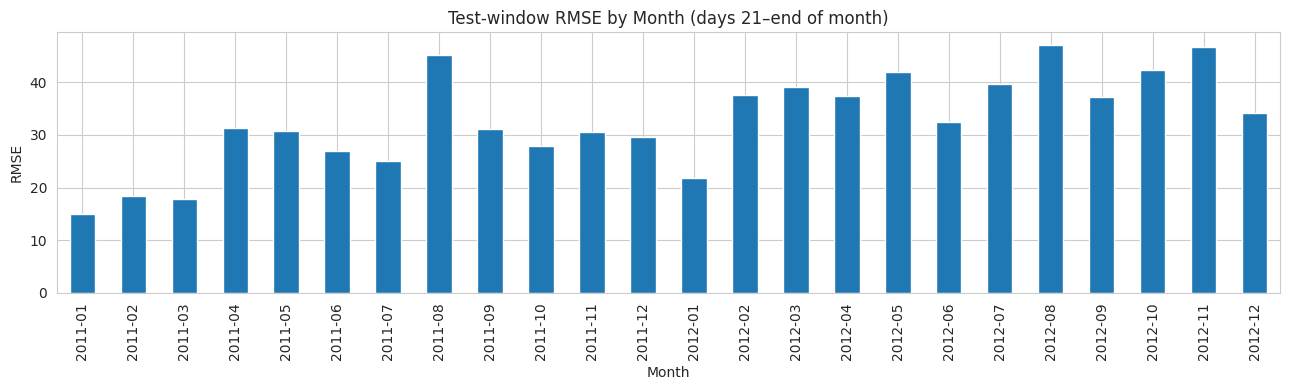

In [25]:
fig, ax = plt.subplots(figsize=(13,4))
monthly_perf['RMSE'].plot(kind='bar', ax=ax)
ax.set_title('Test-window RMSE by Month (days 21–end of month)')
ax.set_ylabel('RMSE')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()


### 3.6 Actual vs. predicted — sample window

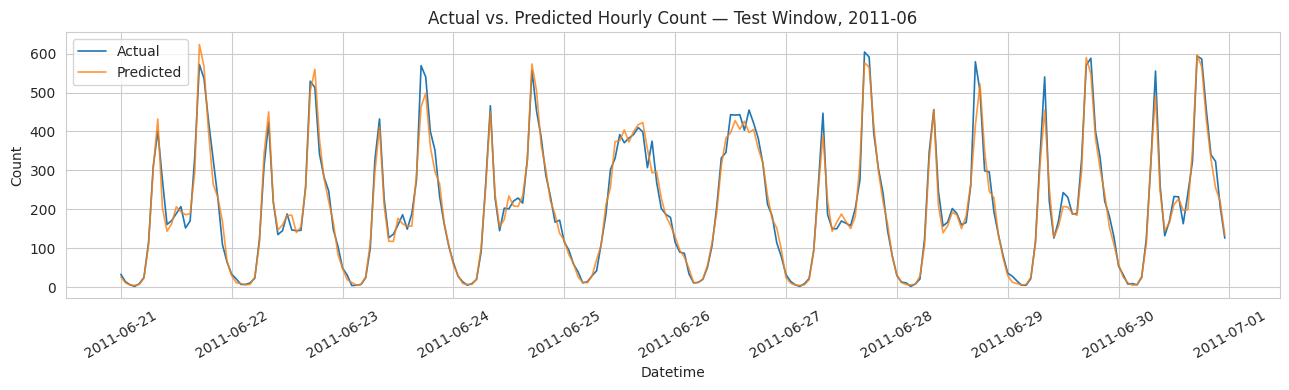

In [26]:
sample_month = test_f_eval['month_year'].unique()[5]   # pick a mid-series month to visualize
sample = test_f_eval[test_f_eval['month_year'] == sample_month].sort_values('datetime')

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(sample['datetime'], sample['count'], label='Actual', linewidth=1.2)
ax.plot(sample['datetime'], sample['pred'], label='Predicted', linewidth=1.2, alpha=0.8)
ax.set_title(f'Actual vs. Predicted Hourly Count — Test Window, {sample_month}')
ax.set_xlabel('Datetime'); ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 3.7 Feature importance

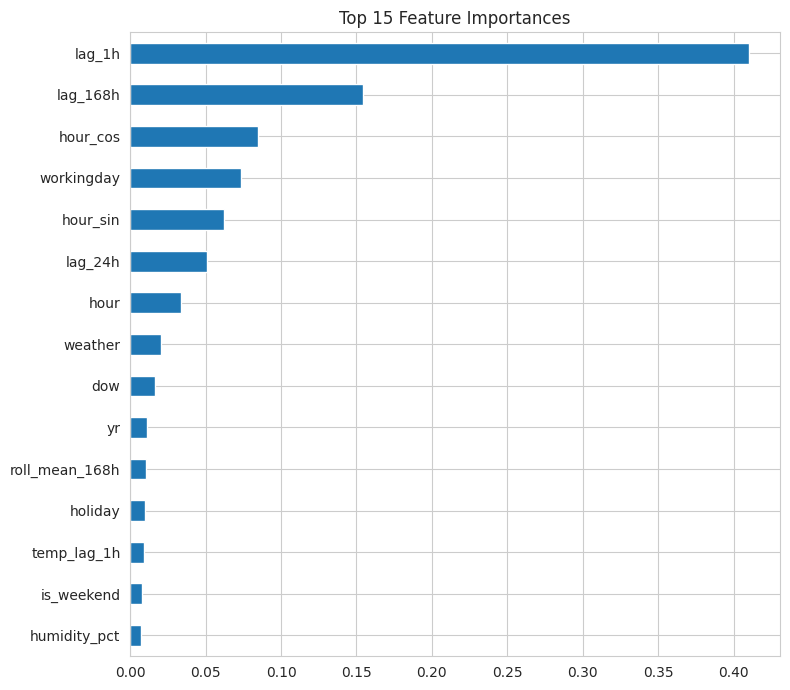

In [27]:
importances = pd.Series(
    (xgb_model.feature_importances_ if HAS_XGB else rf.feature_importances_),
    index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,7))
importances.head(15).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()
